# A04 — CIFAR-10
## Baseline CNN → Improved CNN → PyTorch → TensorFlow/Keras

Đây là dataset thứ ba trong Assignment 04, tiếp nối:

```text
1. MNIST
2. Fashion-MNIST
3. CIFAR-10  ← notebook này
```

CIFAR-10 khó hơn hai dataset trước vì:

- ảnh **RGB 3 kênh** thay vì grayscale;
- kích thước `32 × 32`;
- vật thể có background/phối cảnh/texture đa dạng hơn;
- nhiều class có hình dạng gần nhau.

Flow notebook:

```text
CIFAR-10
│
├── Load dữ liệu Kaggle
├── EDA
├── Train / Validation / Test split
│
├── PyTorch
│   ├── Baseline CNN
│   └── Improved CNN
│
├── TensorFlow / Keras
│   ├── Baseline CNN
│   └── Improved CNN
│
└── Evaluation
    ├── Accuracy
    ├── Precision / Recall / F1
    ├── Loss
    ├── Parameters
    ├── Training time
    ├── Confusion matrix
    ├── Per-class accuracy
    └── Prediction sai
```

### NumPy From Scratch

CNN From Scratch bằng NumPy đã được triển khai đầy đủ ở notebook MNIST.  
Ở dataset thứ ba, ta tập trung vào việc **tái sử dụng ý tưởng CNN trên dữ liệu RGB phức tạp hơn** và so sánh Baseline/Improved trên PyTorch/TensorFlow.

### Output

Theo yêu cầu, **mọi output được lưu cùng folder với file `.ipynb`**, dự kiến:

```text
a04/notebook/CIFAR_10/
```

# 0. Thư viện cần thiết

Environment `train-model`:

```bash
pip install numpy pandas matplotlib scikit-learn pillow torch torchvision tensorflow jupyter ipykernel
```

Nếu đã chạy MNIST/Fashion-MNIST thành công thì gần như không cần cài thêm.

# 1. Import và cấu hình

In [1]:
from pathlib import Path
import time
import random
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("NumPy :", np.__version__)
print("Pandas:", pd.__version__)

NumPy : 2.3.3
Pandas: 3.0.3


# 2. Tự tìm dataset và folder output

Notebook hỗ trợ layout Kaggle Competition phổ biến:

```text
a04/data/CIFAR-10/
├── train/
│   ├── 1.png
│   ├── 2.png
│   └── ...
├── trainLabels.csv
├── train.7z                 # có thể còn hoặc không
├── test.7z                  # không cần cho notebook này
└── sampleSubmission.csv
```

`test.7z` của Kaggle Competition **không có ground-truth label**, nên notebook không dùng tập test competition để đánh giá.

Thay vào đó:

```text
50,000 ảnh train có label
→ train
→ validation
→ test nội bộ
```

Việc này cho phép tính Accuracy / F1 / Confusion Matrix đầy đủ.

In [ ]:
def find_a04_root():
    current = Path.cwd().resolve()

    for base in [current, *current.parents]:
        # Nếu cwd nằm ngoài a04
        candidate = base / "a04"
        if (candidate / "data").exists():
            return candidate

        # Nếu cwd đang nằm bên trong a04
        if base.name.lower() == "a04" and (base / "data").exists():
            return base

    raise FileNotFoundError("Không tìm thấy thư mục a04/data từ working directory hiện tại.")


A04_ROOT = find_a04_root()

# Hỗ trợ một số cách đặt tên folder.
dataset_candidates = [
    A04_ROOT / "data" / "CIFAR-10",
    A04_ROOT / "data" / "CIFAR10",
    A04_ROOT / "data" / "cifar-10",
    A04_ROOT / "data" / "cifar10",
]

DATA_DIR = next(
    (path for path in dataset_candidates if path.exists()),
    None,
)

if DATA_DIR is None:
    raise FileNotFoundError("Không tìm thấy folder CIFAR-10 trong a04/data/.")

OUTPUT_DIR = A04_ROOT / "notebook" / "CIFAR_10"

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

LABELS_CSV = DATA_DIR / "trainLabels.csv"

print("A04_ROOT   :", A04_ROOT)
print("DATA_DIR   :", DATA_DIR)
print("OUTPUT_DIR :", OUTPUT_DIR)
print("LABELS_CSV :", LABELS_CSV)

A04_ROOT   : C:\Users\datng\Desktop\GIÁO TRÌNH\NĂM 4 - KÌ 1\PTCHTTH - Phát Triển Các Hệ Thống Thông Minh\test\a04
DATA_DIR   : C:\Users\datng\Desktop\GIÁO TRÌNH\NĂM 4 - KÌ 1\PTCHTTH - Phát Triển Các Hệ Thống Thông Minh\test\a04\data\CIFAR-10
OUTPUT_DIR : C:\Users\datng\Desktop\GIÁO TRÌNH\NĂM 4 - KÌ 1\PTCHTTH - Phát Triển Các Hệ Thống Thông Minh\test\a04\notebook\CIFAR_10
LABELS_CSV : C:\Users\datng\Desktop\GIÁO TRÌNH\NĂM 4 - KÌ 1\PTCHTTH - Phát Triển Các Hệ Thống Thông Minh\test\a04\data\CIFAR-10\trainLabels.csv


## 2.1. Tìm folder chứa ảnh train

In [ ]:
def find_train_image_dir(data_dir):
    # Các vị trí thường gặp sau khi extract train.7z
    candidates = [
        data_dir / "train",
        data_dir / "Train",
        data_dir / "cifar-10" / "train",
    ]

    for folder in candidates:
        if folder.exists():
            sample_images = list(folder.glob("*.png"))

            if sample_images:
                return folder

            # Có thể archive tạo thêm một folder con.
            nested = list(folder.rglob("*.png"))

            if nested:
                return nested[0].parent

    # Fallback: tìm bất kỳ folder nào có ảnh png.
    png_files = list(data_dir.rglob("*.png"))

    if png_files:
        # Chọn parent phổ biến nhất trong vài nghìn file đầu.
        parents = pd.Series([str(p.parent) for p in png_files[:5000]])

        most_common_parent = Path(parents.value_counts().index[0])

        return most_common_parent

    archive = data_dir / "train.7z"

    if archive.exists():
        raise FileNotFoundError(
            "Đã thấy train.7z nhưng chưa thấy ảnh PNG. "
            "Hãy extract train.7z trước khi chạy notebook."
        )

    raise FileNotFoundError("Không tìm thấy ảnh train CIFAR-10 (*.png).")


TRAIN_IMAGE_DIR = find_train_image_dir(DATA_DIR)

print("TRAIN_IMAGE_DIR:", TRAIN_IMAGE_DIR)

TRAIN_IMAGE_DIR: C:\Users\datng\Desktop\GIÁO TRÌNH\NĂM 4 - KÌ 1\PTCHTTH - Phát Triển Các Hệ Thống Thông Minh\test\a04\data\CIFAR-10\train


# 3. Load label CSV và kiểm tra dữ liệu

In [ ]:
if not LABELS_CSV.exists():
    raise FileNotFoundError(f"Không tìm thấy {LABELS_CSV}")

labels_df = pd.read_csv(LABELS_CSV)

print("Labels shape:", labels_df.shape)
display(labels_df.head())

expected_columns = {"id", "label"}

if not expected_columns.issubset(labels_df.columns):
    raise ValueError("trainLabels.csv cần có hai cột: id và label.")

Labels shape: (50000, 2)


,id,label
0,1,frog
1,2,truck
2,3,truck
3,4,deer
4,5,automobile


## 3.1. Mapping class

CIFAR-10 có 10 class:

```text
airplane
automobile
bird
cat
deer
dog
frog
horse
ship
truck
```

In [ ]:
CLASS_NAMES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

CLASS_TO_ID = {name: idx for idx, name in enumerate(CLASS_NAMES)}

ID_TO_CLASS = {idx: name for name, idx in CLASS_TO_ID.items()}

unknown_labels = set(labels_df["label"].unique()) - set(CLASS_NAMES)

if unknown_labels:
    raise ValueError(f"Phát hiện label không chuẩn CIFAR-10: {unknown_labels}")

labels_df["label_id"] = labels_df["label"].map(CLASS_TO_ID).astype(np.int64)

display(labels_df.head())

,id,label,label_id
0,1,frog,6
1,2,truck,9
2,3,truck,9
3,4,deer,4
4,5,automobile,1


## 3.2. Ghép id với file ảnh

In [ ]:
def resolve_image_path(image_id):
    # Kaggle competition thường là <id>.png
    direct = TRAIN_IMAGE_DIR / f"{int(image_id)}.png"

    if direct.exists():
        return direct

    # Fallback nếu filename giữ dạng string khác.
    alt = TRAIN_IMAGE_DIR / f"{image_id}.png"

    if alt.exists():
        return alt

    return None


labels_df["image_path"] = labels_df["id"].map(resolve_image_path)

missing_count = labels_df["image_path"].isna().sum()

print("Missing image files:", missing_count)

if missing_count > 0:
    display(labels_df[labels_df["image_path"].isna()].head())

    raise FileNotFoundError(f"Không tìm thấy {missing_count} ảnh tương ứng trainLabels.csv.")

labels_df["image_path"] = labels_df["image_path"].astype(str)

print(
    "Số ảnh hợp lệ:",
    len(labels_df),
)

Missing image files: 0
Số ảnh hợp lệ: 50000


# 4. EDA

## 4.1. Phân bố class

,count
label,
airplane,5000
automobile,5000
bird,5000
cat,5000
deer,5000
dog,5000
frog,5000
horse,5000
ship,5000


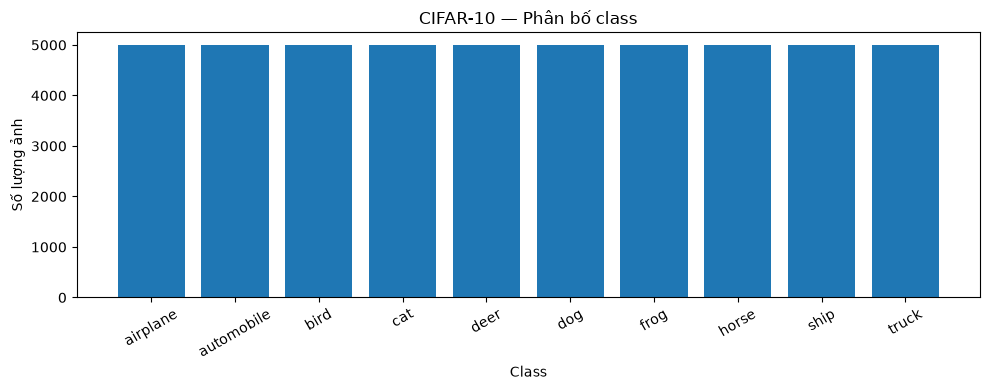

In [ ]:
class_distribution = labels_df["label"].value_counts().reindex(CLASS_NAMES)

display(class_distribution.rename("count").to_frame())

plt.figure(figsize=(10, 4))

plt.bar(
    class_distribution.index,
    class_distribution.values,
)

plt.xlabel("Class")
plt.ylabel("Số lượng ảnh")
plt.title("CIFAR-10 — Phân bố class")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 4.2. Hiển thị ảnh mẫu

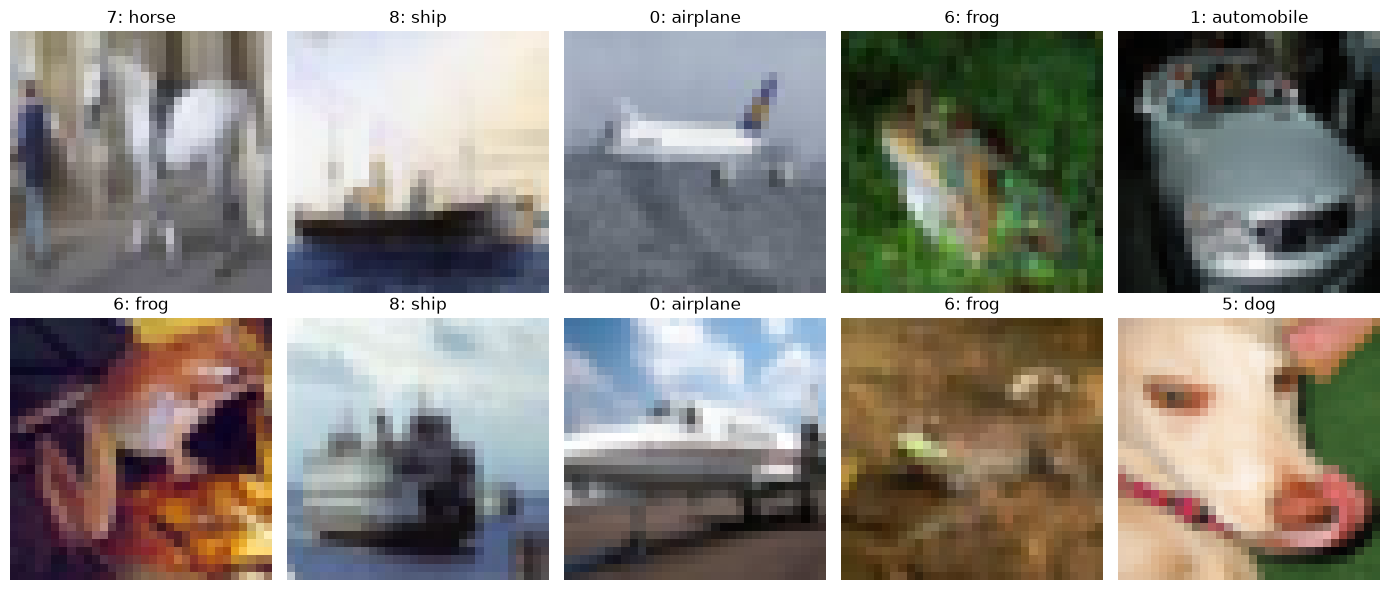

In [ ]:
def show_cifar_samples(
    df,
    n=10,
    random_state=SEED,
):
    sample_df = df.sample(
        n=n,
        random_state=random_state,
    )

    plt.figure(figsize=(14, 6))

    for i, (_, row) in enumerate(
        sample_df.iterrows(),
        start=1,
    ):
        image = Image.open(row["image_path"]).convert("RGB")

        plt.subplot(2, 5, i)
        plt.imshow(image)
        plt.title(f"{row['label_id']}: {row['label']}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_cifar_samples(labels_df)

## 4.3. Kiểm tra kích thước / mode ảnh

In [ ]:
sample_path = Path(labels_df.iloc[0]["image_path"])

with Image.open(sample_path) as img:
    print("Sample:", sample_path.name)
    print("Size  :", img.size)
    print("Mode  :", img.mode)

    assert img.size == (32, 32)

Sample: 1.png
Size  : (32, 32)
Mode  : RGB


# 5. Chia Train / Validation / Test

Kaggle Competition chỉ cung cấp label cho `train/`.

Ta chia 50,000 ảnh labeled theo tỷ lệ:

```text
80% train
10% validation
10% test
```

và dùng `stratify` để giữ phân bố class cân bằng.

In [ ]:
train_df, temp_df = train_test_split(
    labels_df,
    test_size=0.20,
    random_state=SEED,
    stratify=labels_df["label_id"],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label_id"],
)

train_df = train_df.reset_index(drop=True)

val_df = val_df.reset_index(drop=True)

test_df = test_df.reset_index(drop=True)

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

Train: (40000, 4)
Val  : (5000, 4)
Test : (5000, 4)


## 5.1. Chế độ chạy nhanh (tùy chọn)

CIFAR-10 nặng hơn MNIST/Fashion-MNIST đáng kể.

Mặc định:

```python
FAST_MODE = False
```

để train đủ dữ liệu cho kết quả báo cáo.

Nếu chỉ muốn test notebook trước:

```python
FAST_MODE = True
```

Notebook sẽ lấy subset cân bằng nhỏ hơn.

In [ ]:
FAST_MODE = False

if FAST_MODE:

    def stratified_subset(
        df,
        n_samples,
    ):
        n_samples = min(
            n_samples,
            len(df),
        )

        subset, _ = train_test_split(
            df,
            train_size=n_samples,
            random_state=SEED,
            stratify=df["label_id"],
        )

        return subset.reset_index(drop=True)

    train_df = stratified_subset(
        train_df,
        15_000,
    )

    val_df = stratified_subset(
        val_df,
        3_000,
    )

    test_df = stratified_subset(
        test_df,
        3_000,
    )

print("FAST_MODE:", FAST_MODE)
print("Train    :", len(train_df))
print("Val      :", len(val_df))
print("Test     :", len(test_df))

FAST_MODE: False
Train    : 40000
Val      : 5000
Test     : 5000


# PHẦN A — PYTORCH

## Baseline CNN

```text
Input RGB 3×32×32
→ Conv32 → ReLU → Pool
→ Conv64 → ReLU → Pool
→ Flatten
→ Dense128
→ Output10
```

## Improved CNN

```text
Input
→ Conv32 → BN → ReLU
→ Conv32 → BN → ReLU → Pool
→ Conv64 → BN → ReLU
→ Conv64 → BN → ReLU → Pool
→ Conv128 → BN → ReLU
→ Global Average Pooling
→ Dropout
→ Output10
```

Improved còn dùng augmentation:

```text
RandomCrop
RandomHorizontalFlip
```

Điểm quan trọng: CIFAR-10 có nhiều variation về vị trí/hướng, nên augmentation có ý nghĩa hơn trên MNIST.

# 6. Import PyTorch

In [ ]:
import torch
import torch.nn as nn

from torch.utils.data import (
    Dataset,
    DataLoader,
)

from torchvision import transforms

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Device :", DEVICE)

PyTorch: 2.14.0+cpu
Device : cpu


## 6.1. Transform

In [ ]:
# Baseline: chỉ convert ảnh thành tensor [0,1].
baseline_train_transform = transforms.Compose(
    [
        transforms.ToTensor(),
    ]
)

# Improved: thêm augmentation.
improved_train_transform = transforms.Compose(
    [
        transforms.RandomCrop(
            32,
            padding=4,
        ),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
    ]
)

# Validation/Test không augmentation.
eval_transform = transforms.Compose(
    [
        transforms.ToTensor(),
    ]
)

## 6.2. Dataset đọc ảnh lazy từ disk

In [ ]:
class CIFAR10FileDataset(Dataset):
    def __init__(
        self,
        dataframe,
        transform=None,
    ):
        self.df = dataframe.reset_index(drop=True).copy()

        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")

        label = int(row["label_id"])

        if self.transform is not None:
            image = self.transform(image)

        return image, label

## 6.3. DataLoader

In [ ]:
BATCH_SIZE = 128

baseline_train_loader = DataLoader(
    CIFAR10FileDataset(
        train_df,
        baseline_train_transform,
    ),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,  # Windows/Jupyter ổn định hơn.
)

improved_train_loader = DataLoader(
    CIFAR10FileDataset(
        train_df,
        improved_train_transform,
    ),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    CIFAR10FileDataset(
        val_df,
        eval_transform,
    ),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    CIFAR10FileDataset(
        test_df,
        eval_transform,
    ),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

images, labels = next(iter(baseline_train_loader))

print("Image batch:", images.shape)
print("Label batch:", labels.shape)

Image batch: torch.Size([128, 3, 32, 32])
Label batch: torch.Size([128])


# 7. PyTorch Baseline CNN

In [ ]:
class TorchBaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                64 * 8 * 8,
                128,
            ),
            nn.ReLU(),
            nn.Linear(
                128,
                10,
            ),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 8. PyTorch Improved CNN

In [ ]:
class TorchImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(
                32,
                32,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 2
            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(
                64,
                64,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 3
            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            # Không phụ thuộc kích thước spatial cố định.
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.35),
            nn.Linear(
                128,
                10,
            ),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## 8.1. Kiểm tra shape và parameter

In [ ]:
def count_torch_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def inspect_torch_model(
    model,
    sample,
):
    x = sample

    print(
        "Input:",
        tuple(x.shape),
    )

    for idx, layer in enumerate(model.features):
        x = layer(x)

        print(f"features[{idx:02d}] {layer.__class__.__name__:18s} -> {tuple(x.shape)}")

    x = model.classifier(x)

    print(
        "Output:",
        tuple(x.shape),
    )


sample_images, _ = next(iter(baseline_train_loader))

sample_images = sample_images[:4].to(DEVICE)

torch_baseline = TorchBaselineCNN().to(DEVICE)

torch_improved = TorchImprovedCNN().to(DEVICE)

print("BASELINE")
inspect_torch_model(
    torch_baseline,
    sample_images,
)

print(
    "Parameters:",
    f"{count_torch_params(torch_baseline):,}",
)

print("\nIMPROVED")
inspect_torch_model(
    torch_improved,
    sample_images,
)

print(
    "Parameters:",
    f"{count_torch_params(torch_improved):,}",
)

BASELINE
Input: (4, 3, 32, 32)
features[00] Conv2d             -> (4, 32, 32, 32)
features[01] ReLU               -> (4, 32, 32, 32)
features[02] MaxPool2d          -> (4, 32, 16, 16)
features[03] Conv2d             -> (4, 64, 16, 16)
features[04] ReLU               -> (4, 64, 16, 16)
features[05] MaxPool2d          -> (4, 64, 8, 8)
Output: (4, 10)
Parameters: 545,098

IMPROVED
Input: (4, 3, 32, 32)
features[00] Conv2d             -> (4, 32, 32, 32)
features[01] BatchNorm2d        -> (4, 32, 32, 32)
features[02] ReLU               -> (4, 32, 32, 32)
features[03] Conv2d             -> (4, 32, 32, 32)
features[04] BatchNorm2d        -> (4, 32, 32, 32)
features[05] ReLU               -> (4, 32, 32, 32)
features[06] MaxPool2d          -> (4, 32, 16, 16)
features[07] Conv2d             -> (4, 64, 16, 16)
features[08] BatchNorm2d        -> (4, 64, 16, 16)
features[09] ReLU               -> (4, 64, 16, 16)
features[10] Conv2d             -> (4, 64, 16, 16)
features[11] BatchNorm2d        -> (

# 9. Train / Evaluate PyTorch

In [ ]:
def train_torch_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        logits = model(images)

        loss = criterion(
            logits,
            labels,
        )

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        pred = logits.argmax(dim=1)

        correct += (pred == labels).sum().item()

        total += labels.size(0)

    return (
        running_loss / total,
        correct / total,
    )


@torch.no_grad()
def evaluate_torch(
    model,
    loader,
    criterion,
):
    model.eval()

    running_loss = 0.0

    y_true = []
    y_pred = []

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        logits = model(images)

        loss = criterion(
            logits,
            labels,
        )

        pred = logits.argmax(dim=1)

        running_loss += loss.item() * images.size(0)

        y_true.extend(labels.cpu().numpy())

        y_pred.extend(pred.cpu().numpy())

    y_true = np.asarray(y_true)

    y_pred = np.asarray(y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    return {
        "loss": (running_loss / len(loader.dataset)),
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "y_true": y_true,
        "y_pred": y_pred,
    }


def fit_torch(
    model,
    train_loader,
    epochs=10,
    learning_rate=1e-3,
):
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
    )

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
    }

    start = time.perf_counter()

    for epoch in range(
        1,
        epochs + 1,
    ):
        train_loss, train_acc = train_torch_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
        )

        val_result = evaluate_torch(
            model,
            val_loader,
            criterion,
        )

        history["train_loss"].append(train_loss)

        history["train_accuracy"].append(train_acc)

        history["val_loss"].append(val_result["loss"])

        history["val_accuracy"].append(val_result["accuracy"])

        print(
            f"[PyTorch] Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"train_acc={train_acc:.4f} | "
            f"val_loss={val_result['loss']:.4f} | "
            f"val_acc={val_result['accuracy']:.4f}"
        )

    elapsed = time.perf_counter() - start

    return (
        history,
        elapsed,
    )

## 9.1. Hàm vẽ learning curve

In [ ]:
def plot_history(
    history,
    title,
):
    epochs = range(
        1,
        len(history["train_loss"]) + 1,
    )

    plt.figure(figsize=(8, 4))

    plt.plot(
        epochs,
        history["train_loss"],
        marker="o",
        label="Train Loss",
    )

    plt.plot(
        epochs,
        history["val_loss"],
        marker="o",
        label="Val Loss",
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} — Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))

    plt.plot(
        epochs,
        history["train_accuracy"],
        marker="o",
        label="Train Accuracy",
    )

    plt.plot(
        epochs,
        history["val_accuracy"],
        marker="o",
        label="Val Accuracy",
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} — Accuracy")
    plt.legend()
    plt.show()

# 10. Train PyTorch Baseline

CIFAR-10 khó hơn nên mặc định `10 epochs`.

Nếu máy CPU chạy quá lâu, có thể giảm xuống `5`.

[PyTorch] Epoch 01/10 | train_loss=1.5978 | train_acc=0.4247 | val_loss=1.3023 | val_acc=0.5404
[PyTorch] Epoch 02/10 | train_loss=1.2198 | train_acc=0.5659 | val_loss=1.1222 | val_acc=0.6056
[PyTorch] Epoch 03/10 | train_loss=1.0737 | train_acc=0.6223 | val_loss=1.0365 | val_acc=0.6428
[PyTorch] Epoch 04/10 | train_loss=0.9742 | train_acc=0.6554 | val_loss=1.0120 | val_acc=0.6552
[PyTorch] Epoch 05/10 | train_loss=0.8889 | train_acc=0.6867 | val_loss=0.9394 | val_acc=0.6720
[PyTorch] Epoch 06/10 | train_loss=0.8250 | train_acc=0.7103 | val_loss=0.9254 | val_acc=0.6780
[PyTorch] Epoch 07/10 | train_loss=0.7642 | train_acc=0.7319 | val_loss=0.9172 | val_acc=0.6872
[PyTorch] Epoch 08/10 | train_loss=0.7063 | train_acc=0.7546 | val_loss=0.8950 | val_acc=0.6960
[PyTorch] Epoch 09/10 | train_loss=0.6503 | train_acc=0.7729 | val_loss=0.8801 | val_acc=0.7044
[PyTorch] Epoch 10/10 | train_loss=0.5968 | train_acc=0.7922 | val_loss=0.8631 | val_acc=0.7072


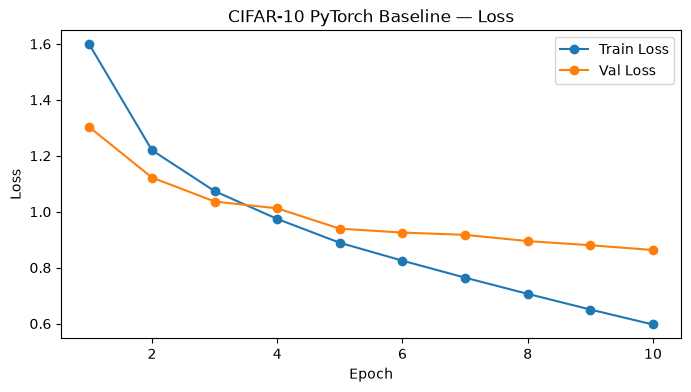

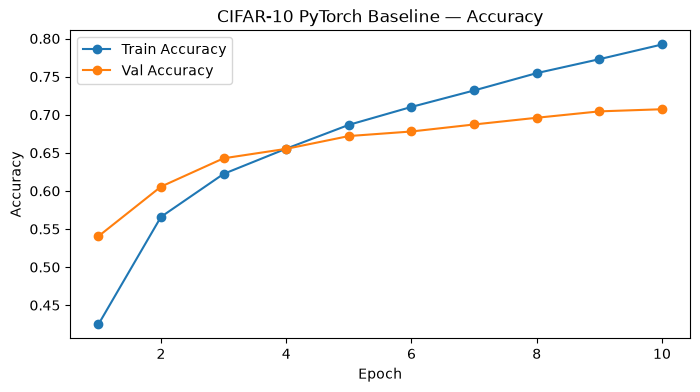

In [ ]:
TORCH_EPOCHS = 10
TORCH_LR = 1e-3

torch.manual_seed(SEED)

torch_baseline = TorchBaselineCNN().to(DEVICE)

torch_baseline_history, torch_baseline_time = fit_torch(
    torch_baseline,
    baseline_train_loader,
    epochs=TORCH_EPOCHS,
    learning_rate=TORCH_LR,
)

plot_history(
    torch_baseline_history,
    "CIFAR-10 PyTorch Baseline",
)

# 11. Train PyTorch Improved

[PyTorch] Epoch 01/10 | train_loss=1.4950 | train_acc=0.4505 | val_loss=1.9512 | val_acc=0.3730
[PyTorch] Epoch 02/10 | train_loss=1.1591 | train_acc=0.5858 | val_loss=1.3056 | val_acc=0.5352
[PyTorch] Epoch 03/10 | train_loss=1.0249 | train_acc=0.6360 | val_loss=1.0921 | val_acc=0.6092
[PyTorch] Epoch 04/10 | train_loss=0.9437 | train_acc=0.6651 | val_loss=1.0745 | val_acc=0.6372
[PyTorch] Epoch 05/10 | train_loss=0.8777 | train_acc=0.6890 | val_loss=0.8219 | val_acc=0.7130
[PyTorch] Epoch 06/10 | train_loss=0.8231 | train_acc=0.7105 | val_loss=0.9810 | val_acc=0.6540
[PyTorch] Epoch 07/10 | train_loss=0.7807 | train_acc=0.7276 | val_loss=1.0634 | val_acc=0.6412
[PyTorch] Epoch 08/10 | train_loss=0.7440 | train_acc=0.7426 | val_loss=0.9264 | val_acc=0.7012
[PyTorch] Epoch 09/10 | train_loss=0.7177 | train_acc=0.7490 | val_loss=0.8646 | val_acc=0.7138
[PyTorch] Epoch 10/10 | train_loss=0.6899 | train_acc=0.7623 | val_loss=0.6737 | val_acc=0.7736


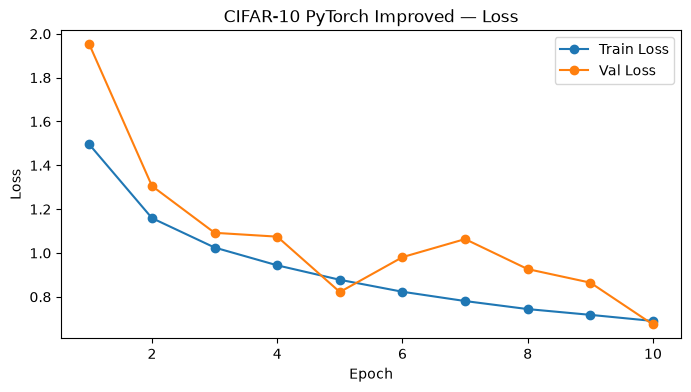

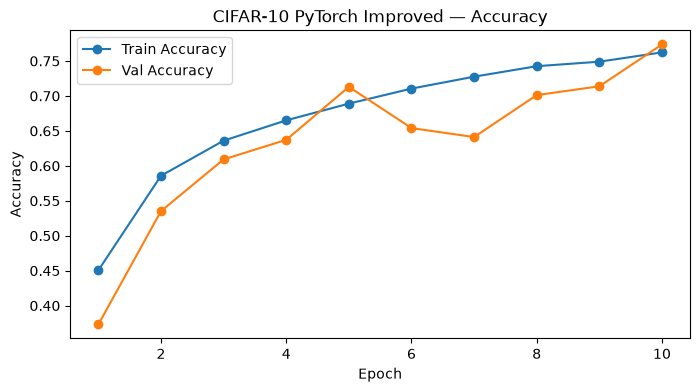

In [ ]:
torch.manual_seed(SEED)

torch_improved = TorchImprovedCNN().to(DEVICE)

torch_improved_history, torch_improved_time = fit_torch(
    torch_improved,
    improved_train_loader,
    epochs=TORCH_EPOCHS,
    learning_rate=TORCH_LR,
)

plot_history(
    torch_improved_history,
    "CIFAR-10 PyTorch Improved",
)

# 12. Test PyTorch

In [ ]:
torch_criterion = nn.CrossEntropyLoss()

torch_baseline_test = evaluate_torch(
    torch_baseline,
    test_loader,
    torch_criterion,
)

torch_improved_test = evaluate_torch(
    torch_improved,
    test_loader,
    torch_criterion,
)

torch_results = pd.DataFrame(
    [
        {
            "Implementation": "PyTorch",
            "Model": "Baseline CNN",
            "Loss": torch_baseline_test["loss"],
            "Accuracy": torch_baseline_test["accuracy"],
            "Precision": torch_baseline_test["precision"],
            "Recall": torch_baseline_test["recall"],
            "F1": torch_baseline_test["f1"],
            "Parameters": count_torch_params(torch_baseline),
            "Train Time (s)": torch_baseline_time,
        },
        {
            "Implementation": "PyTorch",
            "Model": "Improved CNN",
            "Loss": torch_improved_test["loss"],
            "Accuracy": torch_improved_test["accuracy"],
            "Precision": torch_improved_test["precision"],
            "Recall": torch_improved_test["recall"],
            "F1": torch_improved_test["f1"],
            "Parameters": count_torch_params(torch_improved),
            "Train Time (s)": torch_improved_time,
        },
    ]
)

display(torch_results)

,Implementation,Model,Loss,Accuracy,Precision,Recall,F1,Parameters,Train Time (s)
0,PyTorch,Baseline CNN,0.867135,0.7056,0.708476,0.7056,0.704051,545098,667.412694
1,PyTorch,Improved CNN,0.690919,0.7624,0.780480,0.7624,0.761692,141034,694.595731


# PHẦN B — TENSORFLOW / KERAS

TensorFlow sẽ đọc trực tiếp các file PNG bằng `tf.data`.

Ưu điểm:

```text
Không cần load toàn bộ 50,000 ảnh vào RAM
→ đọc theo batch
→ cache/prefetch phù hợp pipeline train
```

# 13. Import TensorFlow

In [ ]:
import tensorflow as tf

tf.random.set_seed(SEED)

print(
    "TensorFlow:",
    tf.__version__,
)

print(
    "GPU devices:",
    tf.config.list_physical_devices("GPU"),
)

TensorFlow: 2.21.0
GPU devices: []


# 14. tf.data pipeline

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE


def decode_cifar_image(
    path,
    label,
):
    image_bytes = tf.io.read_file(path)

    image = tf.image.decode_png(
        image_bytes,
        channels=3,
    )

    image = tf.image.convert_image_dtype(
        image,
        tf.float32,
    )

    image = tf.ensure_shape(
        image,
        [32, 32, 3],
    )

    return image, label


def make_tf_dataset(
    df,
    shuffle=False,
):
    paths = df["image_path"].astype(str).to_numpy()

    labels = df["label_id"].to_numpy(dtype=np.int64)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(
            buffer_size=min(
                len(df),
                20_000,
            ),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    ds = ds.map(
        decode_cifar_image,
        num_parallel_calls=AUTOTUNE,
    )

    ds = ds.batch(BATCH_SIZE)

    ds = ds.prefetch(AUTOTUNE)

    return ds


tf_train_ds = make_tf_dataset(
    train_df,
    shuffle=True,
)

tf_val_ds = make_tf_dataset(
    val_df,
    shuffle=False,
)

tf_test_ds = make_tf_dataset(
    test_df,
    shuffle=False,
)

for images, labels in tf_train_ds.take(1):
    print(
        "TF image batch:",
        images.shape,
    )
    print(
        "TF label batch:",
        labels.shape,
    )

TF image batch: (128, 32, 32, 3)
TF label batch: (128,)


# 15. TensorFlow Baseline CNN

In [ ]:
def build_tf_baseline():
    inputs = tf.keras.Input(shape=(32, 32, 3))

    x = tf.keras.layers.Conv2D(
        32,
        kernel_size=3,
        padding="same",
        activation="relu",
    )(inputs)

    x = tf.keras.layers.MaxPool2D(pool_size=2)(x)

    x = tf.keras.layers.Conv2D(
        64,
        kernel_size=3,
        padding="same",
        activation="relu",
    )(x)

    x = tf.keras.layers.MaxPool2D(pool_size=2)(x)

    x = tf.keras.layers.Flatten()(x)

    x = tf.keras.layers.Dense(
        128,
        activation="relu",
    )(x)

    outputs = tf.keras.layers.Dense(10)(x)

    return tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="CIFAR10_Baseline",
    )


tf_baseline = build_tf_baseline()

tf_baseline.summary()

Model: "CIFAR10_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

# 16. TensorFlow Improved CNN

Improved TensorFlow tương đương ý tưởng PyTorch:

- augmentation;
- nhiều convolution hơn;
- Batch Normalization;
- Global Average Pooling;
- Dropout.

In [ ]:
def build_tf_improved():
    inputs = tf.keras.Input(shape=(32, 32, 3))

    augmentation = tf.keras.Sequential(
        [
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomTranslation(
                height_factor=0.10,
                width_factor=0.10,
            ),
        ],
        name="augmentation",
    )

    x = augmentation(inputs)

    # Block 1
    x = tf.keras.layers.Conv2D(
        32,
        3,
        padding="same",
        use_bias=False,
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.Conv2D(
        32,
        3,
        padding="same",
        use_bias=False,
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.MaxPool2D(2)(x)

    # Block 2
    x = tf.keras.layers.Conv2D(
        64,
        3,
        padding="same",
        use_bias=False,
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.Conv2D(
        64,
        3,
        padding="same",
        use_bias=False,
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.MaxPool2D(2)(x)

    # Block 3
    x = tf.keras.layers.Conv2D(
        128,
        3,
        padding="same",
        use_bias=False,
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    x = tf.keras.layers.Dropout(0.35)(x)

    outputs = tf.keras.layers.Dense(10)(x)

    return tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="CIFAR10_Improved",
    )


tf_improved = build_tf_improved()

tf_improved.summary()

Model: "CIFAR10_Improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,29

 Total params: 141,674 (553.41 KB)

 Trainable params: 141,034 (550.91 KB)

 Non-trainable params: 640 (2.50 KB)

# 17. Train / Evaluate TensorFlow

In [ ]:
def compile_tf_model(
    model,
    learning_rate=1e-3,
):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"],
    )


def fit_tf_model(
    model,
    epochs=10,
    learning_rate=1e-3,
):
    compile_tf_model(
        model,
        learning_rate=learning_rate,
    )

    start = time.perf_counter()

    history = model.fit(
        tf_train_ds,
        validation_data=tf_val_ds,
        epochs=epochs,
        verbose=1,
    )

    elapsed = time.perf_counter() - start

    return (
        history,
        elapsed,
    )


def evaluate_tf_model(
    model,
):
    loss, _ = model.evaluate(
        tf_test_ds,
        verbose=0,
    )

    logits = model.predict(
        tf_test_ds,
        verbose=0,
    )

    pred = logits.argmax(axis=1)

    true = test_df["label_id"].to_numpy(dtype=np.int64)

    precision, recall, f1, _ = precision_recall_fscore_support(
        true,
        pred,
        average="macro",
        zero_division=0,
    )

    return {
        "loss": float(loss),
        "accuracy": accuracy_score(
            true,
            pred,
        ),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "y_true": true,
        "y_pred": pred,
    }

## 17.1. Hàm vẽ TensorFlow history

In [ ]:
def plot_tf_history(
    history,
    title,
):
    h = history.history

    epochs = range(
        1,
        len(h["loss"]) + 1,
    )

    plt.figure(figsize=(8, 4))

    plt.plot(
        epochs,
        h["loss"],
        marker="o",
        label="Train Loss",
    )

    plt.plot(
        epochs,
        h["val_loss"],
        marker="o",
        label="Val Loss",
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} — Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))

    plt.plot(
        epochs,
        h["accuracy"],
        marker="o",
        label="Train Accuracy",
    )

    plt.plot(
        epochs,
        h["val_accuracy"],
        marker="o",
        label="Val Accuracy",
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} — Accuracy")
    plt.legend()
    plt.show()

# 18. Train TensorFlow Baseline

Epoch 1/10


c:\Users\datng\miniconda3\envs\llm_agent\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.4354 - loss: 1.5782 - val_accuracy: 0.5274 - val_loss: 1.3086
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.5688 - loss: 1.2130 - val_accuracy: 0.5884 - val_loss: 1.1586
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.6309 - loss: 1.0557 - val_accuracy: 0.6186 - val_loss: 1.0760
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.6624 - loss: 0.9655 - val_accuracy: 0.6504 - val_loss: 1.0096
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.6894 - loss: 0.8934 - val_accuracy: 0.6620 - val_loss: 0.9601
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.7096 - loss: 0.8359 - val_accuracy: 0.6836 - val_loss: 0.9024
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.7282 - loss: 0.7811 - val_accuracy: 0.6872 - val_loss: 0.9035
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.7464 - loss: 0.7316 - val_accuracy: 0

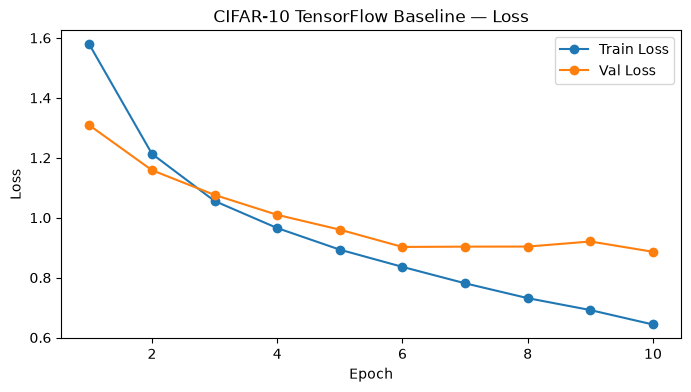

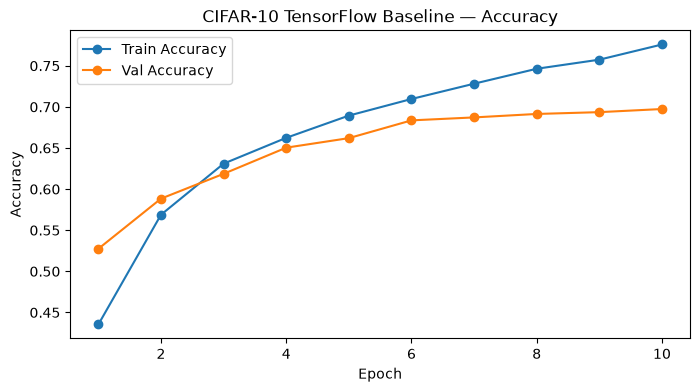

In [ ]:
TF_EPOCHS = 10
TF_LR = 1e-3

tf.random.set_seed(SEED)

tf_baseline = build_tf_baseline()

tf_baseline_history, tf_baseline_time = fit_tf_model(
    tf_baseline,
    epochs=TF_EPOCHS,
    learning_rate=TF_LR,
)

plot_tf_history(
    tf_baseline_history,
    "CIFAR-10 TensorFlow Baseline",
)

# 19. Train TensorFlow Improved

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 116ms/step - accuracy: 0.4318 - loss: 1.5526 - val_accuracy: 0.2510 - val_loss: 2.2989
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 115ms/step - accuracy: 0.5694 - loss: 1.2060 - val_accuracy: 0.3236 - val_loss: 2.3401
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 112ms/step - accuracy: 0.6204 - loss: 1.0678 - val_accuracy: 0.5658 - val_loss: 1.2321
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 116ms/step - accuracy: 0.6546 - loss: 0.9836 - val_accuracy: 0.5690 - val_loss: 1.1711
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 112ms/step - accuracy: 0.6811 - loss: 0.9080 - val_accuracy: 0.5934 - val_loss: 1.2109
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 117ms/step - accuracy: 0.6960 - loss: 0.8638 - val_accuracy: 0.5984 - val_loss: 1.1781
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 113ms/step - accuracy: 0.7125 - loss: 0.8200 - val_accuracy: 0.6974 - val_loss: 0.8847
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 115ms/step - accuracy: 0.7280 - loss: 0

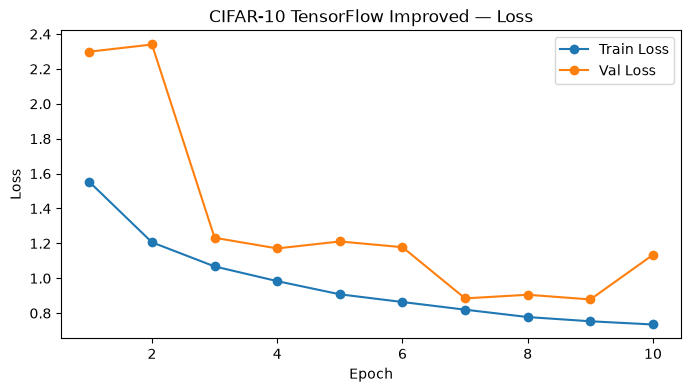

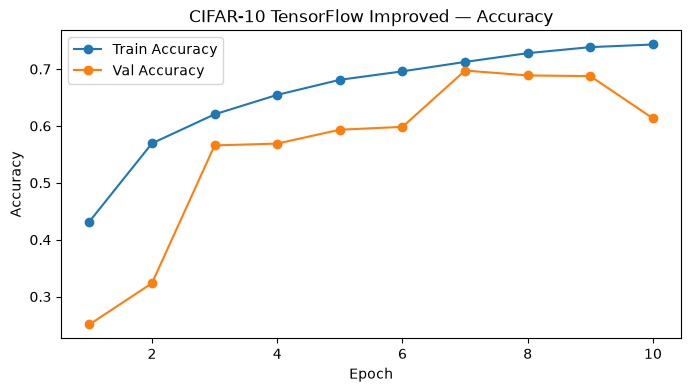

In [ ]:
tf.random.set_seed(SEED)

tf_improved = build_tf_improved()

tf_improved_history, tf_improved_time = fit_tf_model(
    tf_improved,
    epochs=TF_EPOCHS,
    learning_rate=TF_LR,
)

plot_tf_history(
    tf_improved_history,
    "CIFAR-10 TensorFlow Improved",
)

# 20. Test TensorFlow

In [ ]:
tf_baseline_test = evaluate_tf_model(tf_baseline)

tf_improved_test = evaluate_tf_model(tf_improved)

tf_results = pd.DataFrame(
    [
        {
            "Implementation": "TensorFlow",
            "Model": "Baseline CNN",
            "Loss": tf_baseline_test["loss"],
            "Accuracy": tf_baseline_test["accuracy"],
            "Precision": tf_baseline_test["precision"],
            "Recall": tf_baseline_test["recall"],
            "F1": tf_baseline_test["f1"],
            "Parameters": tf_baseline.count_params(),
            "Train Time (s)": tf_baseline_time,
        },
        {
            "Implementation": "TensorFlow",
            "Model": "Improved CNN",
            "Loss": tf_improved_test["loss"],
            "Accuracy": tf_improved_test["accuracy"],
            "Precision": tf_improved_test["precision"],
            "Recall": tf_improved_test["recall"],
            "F1": tf_improved_test["f1"],
            "Parameters": tf_improved.count_params(),
            "Train Time (s)": tf_improved_time,
        },
    ]
)

display(tf_results)

,Implementation,Model,Loss,Accuracy,Precision,Recall,F1,Parameters,Train Time (s)
0,TensorFlow,Baseline CNN,0.916590,0.6922,0.703499,0.6922,0.693490,545098,95.891351
1,TensorFlow,Improved CNN,1.173394,0.6124,0.721060,0.6124,0.600994,141674,361.095918


# PHẦN C — ĐÁNH GIÁ VÀ SO SÁNH

# 21. Bảng tổng hợp

In [ ]:
all_results = pd.concat(
    [
        torch_results,
        tf_results,
    ],
    ignore_index=True,
)

display(
    all_results.style.format(
        {
            "Loss": "{:.4f}",
            "Accuracy": "{:.4f}",
            "Precision": "{:.4f}",
            "Recall": "{:.4f}",
            "F1": "{:.4f}",
            "Parameters": "{:,.0f}",
            "Train Time (s)": "{:.2f}",
        }
    )
)

,Implementation,Model,Loss,Accuracy,Precision,Recall,F1,Parameters,Train Time (s)
0,PyTorch,Baseline CNN,0.8671,0.7056,0.7085,0.7056,0.7041,"545,098",667.41
1,PyTorch,Improved CNN,0.6909,0.7624,0.7805,0.7624,0.7617,"141,034",694.60
2,TensorFlow,Baseline CNN,0.9166,0.6922,0.7035,0.6922,0.6935,"545,098",95.89
3,TensorFlow,Improved CNN,1.1734,0.6124,0.7211,0.6124,0.6010,"141,674",361.10


# 22. Biểu đồ Accuracy

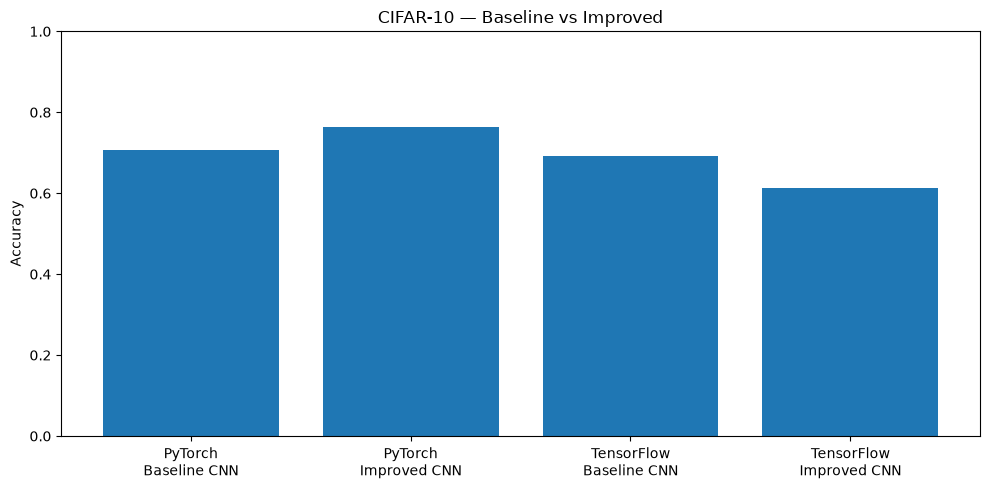

In [ ]:
chart_labels = all_results["Implementation"] + "\n" + all_results["Model"]

plt.figure(figsize=(10, 5))

plt.bar(
    chart_labels,
    all_results["Accuracy"],
)

plt.ylabel("Accuracy")
plt.title("CIFAR-10 — Baseline vs Improved")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# 23. Confusion Matrix — PyTorch Improved

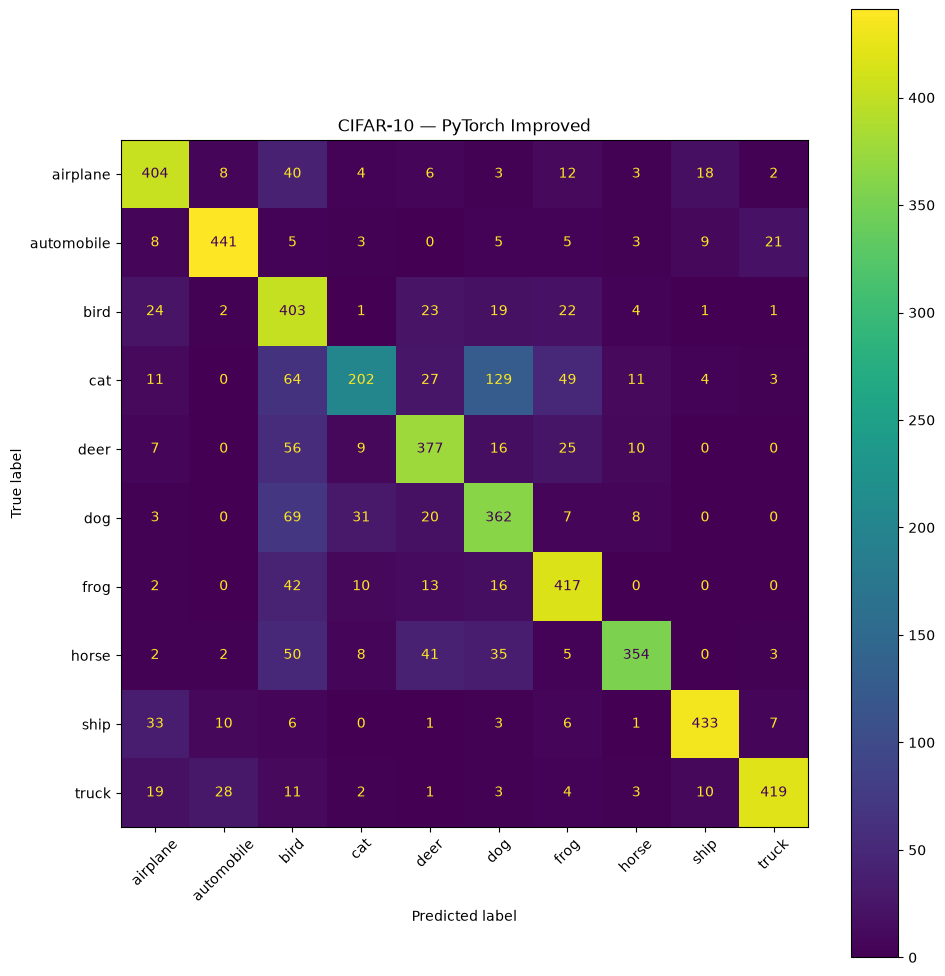

In [ ]:
cm = confusion_matrix(
    torch_improved_test["y_true"],
    torch_improved_test["y_pred"],
)

fig, ax = plt.subplots(figsize=(10, 10))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES,
).plot(
    ax=ax,
    values_format="d",
    xticks_rotation=45,
)

plt.title("CIFAR-10 — PyTorch Improved")
plt.tight_layout()
plt.show()

# 24. Classification Report — PyTorch Improved

In [37]:
print(
    classification_report(
        torch_improved_test["y_true"],
        torch_improved_test["y_pred"],
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

    airplane     0.7875    0.8080    0.7976       500
  automobile     0.8982    0.8820    0.8900       500
        bird     0.5402    0.8060    0.6469       500
         cat     0.7481    0.4040    0.5247       500
        deer     0.7407    0.7540    0.7473       500
         dog     0.6125    0.7240    0.6636       500
        frog     0.7554    0.8340    0.7928       500
       horse     0.8917    0.7080    0.7893       500
        ship     0.9116    0.8660    0.8882       500
       truck     0.9189    0.8380    0.8766       500

    accuracy                         0.7624      5000
   macro avg     0.7805    0.7624    0.7617      5000
weighted avg     0.7805    0.7624    0.7617      5000



# 25. Accuracy từng class

In [38]:
def build_per_class_accuracy(
    y_true,
    y_pred,
):
    rows = []

    for label, name in enumerate(CLASS_NAMES):
        mask = y_true == label

        total = int(mask.sum())

        correct = int((y_pred[mask] == label).sum())

        rows.append(
            {
                "Label": label,
                "Class": name,
                "Samples": total,
                "Correct": correct,
                "Accuracy": (correct / total if total > 0 else np.nan),
            }
        )

    return pd.DataFrame(rows)


per_class_df = build_per_class_accuracy(
    torch_improved_test["y_true"],
    torch_improved_test["y_pred"],
)

display(per_class_df.style.format({"Accuracy": "{:.4f}"}))

,Label,Class,Samples,Correct,Accuracy
0,0,airplane,500,404,0.8080
1,1,automobile,500,441,0.8820
2,2,bird,500,403,0.8060
3,3,cat,500,202,0.4040
4,4,deer,500,377,0.7540
5,5,dog,500,362,0.7240
6,6,frog,500,417,0.8340
7,7,horse,500,354,0.7080
8,8,ship,500,433,0.8660
9,9,truck,500,419,0.8380


# 26. Xem prediction sai

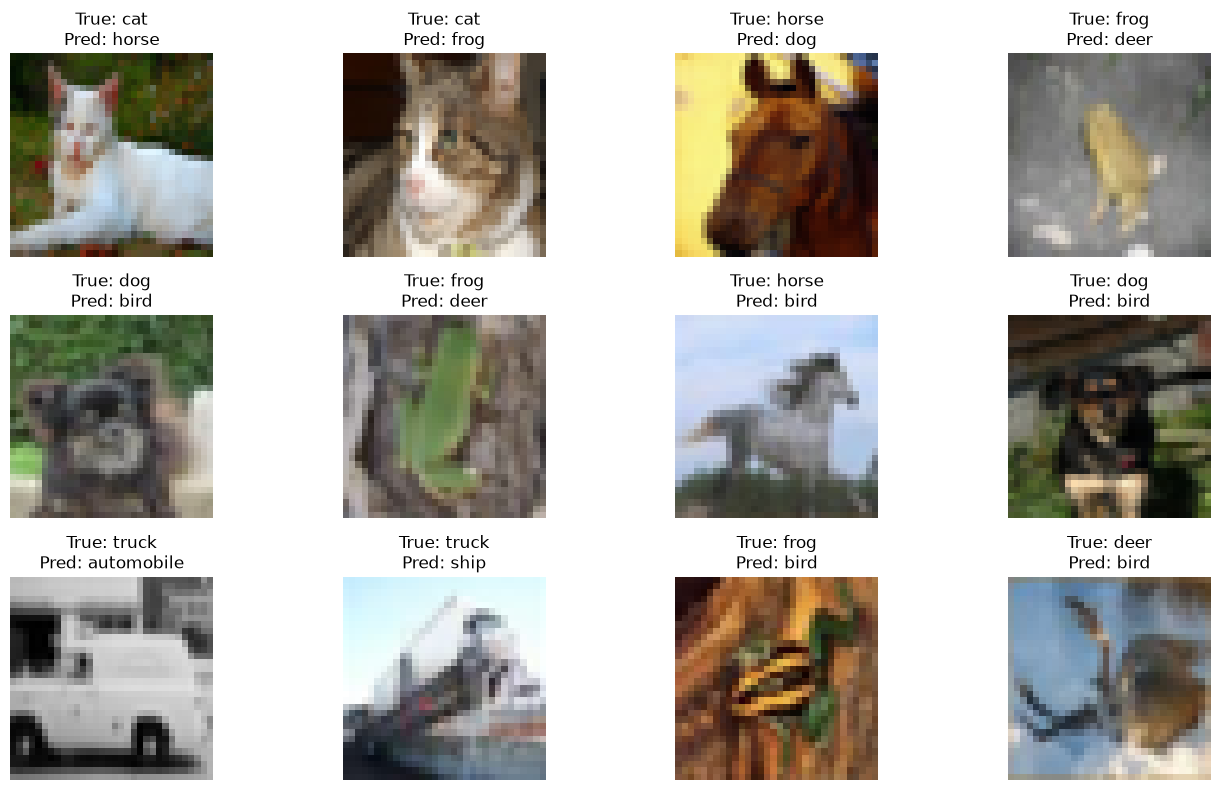

In [39]:
@torch.no_grad()
def collect_mistakes(
    model,
    dataframe,
    max_items=12,
):
    model.eval()

    dataset = CIFAR10FileDataset(
        dataframe,
        eval_transform,
    )

    loader = DataLoader(
        dataset,
        batch_size=128,
        shuffle=False,
        num_workers=0,
    )

    mistakes = []

    for images, labels in loader:
        images_device = images.to(DEVICE)

        labels_device = labels.to(DEVICE)

        logits = model(images_device)

        pred = logits.argmax(dim=1)

        wrong = pred != labels_device

        wrong_images = images[wrong.cpu()]

        wrong_true = labels[wrong.cpu()]

        wrong_pred = pred[wrong].cpu()

        for image, true_label, pred_label in zip(
            wrong_images,
            wrong_true,
            wrong_pred,
        ):
            mistakes.append(
                (
                    image.permute(1, 2, 0).numpy(),
                    int(true_label),
                    int(pred_label),
                )
            )

            if len(mistakes) >= max_items:
                return mistakes

    return mistakes


mistakes = collect_mistakes(
    torch_improved,
    test_df,
    max_items=12,
)

plt.figure(figsize=(14, 8))

for idx, (
    image,
    true_label,
    pred_label,
) in enumerate(
    mistakes,
    start=1,
):
    plt.subplot(
        3,
        4,
        idx,
    )

    plt.imshow(image)

    plt.title(f"True: {ID_TO_CLASS[true_label]}\nPred: {ID_TO_CLASS[pred_label]}")

    plt.axis("off")

plt.tight_layout()
plt.show()

# 27. Phân tích lỗi thường gặp

Một số cặp CIFAR-10 thường dễ nhầm:

```text
cat ↔ dog
automobile ↔ truck
airplane ↔ ship
deer ↔ horse
bird ↔ airplane
```

Không nên chỉ nhìn Accuracy tổng.

Hãy dùng:

- confusion matrix;
- per-class accuracy;
- ảnh prediction sai;

để giải thích model đang khó ở đâu.

# 28. Lưu output CÙNG FOLDER NOTEBOOK

File sinh ra:

```text
a04/notebook/CIFAR_10/
├── A04_CIFAR10_CNN.ipynb
├── cifar10_torch_baseline.pt
├── cifar10_torch_improved.pt
├── cifar10_tf_baseline.keras
├── cifar10_tf_improved.keras
├── cifar10_results.csv
├── cifar10_per_class_accuracy.csv
├── cifar10_train_split.csv
├── cifar10_val_split.csv
└── cifar10_test_split.csv
```

Lưu cả split giúp kết quả có thể tái lập chính xác.

In [ ]:
# -----------------------------
# PyTorch weights
# -----------------------------
torch.save(
    torch_baseline.state_dict(),
    OUTPUT_DIR / "cifar10_torch_baseline.pt",
)

torch.save(
    torch_improved.state_dict(),
    OUTPUT_DIR / "cifar10_torch_improved.pt",
)

# -----------------------------
# TensorFlow models
# -----------------------------
tf_baseline.save(OUTPUT_DIR / "cifar10_tf_baseline.keras")

tf_improved.save(OUTPUT_DIR / "cifar10_tf_improved.keras")

# -----------------------------
# Metrics
# -----------------------------
all_results.to_csv(
    OUTPUT_DIR / "cifar10_results.csv",
    index=False,
)

per_class_df.to_csv(
    OUTPUT_DIR / "cifar10_per_class_accuracy.csv",
    index=False,
)

# -----------------------------
# Dataset split
# -----------------------------
split_columns = [
    "id",
    "label",
    "label_id",
    "image_path",
]

train_df[split_columns].to_csv(
    OUTPUT_DIR / "cifar10_train_split.csv",
    index=False,
)

val_df[split_columns].to_csv(
    OUTPUT_DIR / "cifar10_val_split.csv",
    index=False,
)

test_df[split_columns].to_csv(
    OUTPUT_DIR / "cifar10_test_split.csv",
    index=False,
)

print("Đã lưu toàn bộ output tại:")
print(OUTPUT_DIR.resolve())

Đã lưu toàn bộ output tại:
C:\Users\datng\Desktop\GIÁO TRÌNH\NĂM 4 - KÌ 1\PTCHTTH - Phát Triển Các Hệ Thống Thông Minh\test\a04\notebook\CIFAR_10


# 29. Gợi ý nội dung kết luận cho A04

Sau khi chạy notebook, hãy viết nhận xét từ **kết quả thực tế**, không mặc định Improved phải thắng.

## Dataset

```text
CIFAR-10
50,000 labeled training images trong Kaggle competition
32×32 RGB
10 classes
```

Trong notebook ta chia:

```text
80% train
10% validation
10% internal test
```

## Baseline CNN

Mục tiêu:

```text
thiết lập một mốc CNN đơn giản
```

## Improved CNN

Các cải tiến:

```text
deeper CNN
+ Batch Normalization
+ Data Augmentation
+ Global Average Pooling
+ Dropout
```

## So sánh

Cần bàn:

- Improved có tăng Accuracy/F1 không?
- Đổi lại số parameter / thời gian train thay đổi thế nào?
- PyTorch và TensorFlow cho kết quả có gần nhau không?
- Class nào khó nhất?
- Cặp class nào bị nhầm nhiều nhất?
- CIFAR-10 khó hơn MNIST và Fashion-MNIST ra sao?

---

# Tổng flow Assignment 04 sau khi hoàn thành notebook này

```text
                    ASSIGNMENT 04
                         │
        ┌────────────────┼────────────────┐
        │                │                │
      MNIST        Fashion-MNIST       CIFAR-10
        │                │                │
        │                │                │
 NumPy Scratch      Baseline          Baseline
 PyTorch            Improved          Improved
 TensorFlow         PyTorch           PyTorch
 Baseline/Improved  TensorFlow        TensorFlow
        │                │                │
        └────────────────┼────────────────┘
                         │
                    Evaluation
                         │
              Accuracy / F1 / Loss
                         │
               Confusion Matrix
                         │
                 Error Analysis
                         │
                     Report
```